# Annotation agreement and model errors across Image, FEA, and Multimodal FER

This notebook analyzes whether **human annotation agreement** is associated with recognition performance and error patterns for all three final dynamic FER modalities:

- **Image sequence model**
- **FEA sequence model**
- **Multimodal sequence model**

The analysis compares retained reenactments with **3/3 versus 2/3 agreement with the prompted/retained label**.

### Analysis units

The primary performance analysis follows the same evaluation units used for the dynamic model results:

- **Image:** both camera views, 756 view-level predictions from 378 reenactments;
- **FEA:** one prediction per reenactment, 378 predictions;
- **Multimodal:** both camera views, 756 view-level predictions from 378 reenactments.

Image and Multimodal percentages are therefore directly comparable as performance rates, but the 756 view rows are **not 756 independent reenactments**. Central and side views originate from the same 378 reenactments. Participant-cluster bootstrap analyses preserve this dependence structure.

### Annotation scope

Three human raters labeled one selected, HMD-occluded **central-view reference image** per reenactment. These ratings are not independent annotations of the full image sequence, the side view, or the FEA sequence. The benchmark inherited the reference-image label.

Agreement therefore measures human agreement on the selected reference image, not objective sequence-label correctness. The analysis does not relabel any sample.

### Main analyses

The notebook includes:

- annotation-agreement distributions across all retained SFEA/DFEA samples;
- overall and class-wise performance by agreement level for Image, FEA, and Multimodal models;
- class-level comparison between human agreement and model recall;
- directed error patterns by agreement level;
- correspondence between model errors and the dissenting human label in 2/3 cases;
- Central-versus-Side sensitivity for Image and Multimodal predictions;
- Participant and Participant × Class sensitivity;
- participant-cluster bootstrap intervals and leave-one-participant-out checks.

All analyses are exploratory associations, not causal effects or validated label corrections. Tables, figures, and the report are exported to `outputs/06_label_agreement_and_model_errors/`.


## Embedded input snapshots

The supplied label-analysis notebook already contained compressed snapshots of the annotation table and the shared SFEA/DFEA membership manifest.

For reproducibility, this expanded notebook also contains a prediction snapshot with all three dynamic modalities. The embedded snapshot preserves the supplied notebook's FEA prediction columns and adds Image and Multimodal prediction columns from the current repository prediction export after strict identifier and label checks.

External paths can be set in the following configuration cell to analyze updated files instead.


In [1]:
LABELS_SNAPSHOT = '...'
PREDICTIONS_SNAPSHOT = '...'
MEMBERSHIP_SNAPSHOT = '...'

MEMBERSHIP_SOURCES = [{'dataset': 'SFEA', 'split': 'train', 'filename': 'sfea_train.csv', 'sha256': 'f0f3a9189d281215cd9f27f575131772278f1904e5d944611f539ca4cebf1d44', 'rows': 964, 'reenactments': 964}, {'dataset': 'SFEA', 'split': 'validation', 'filename': 'sfea_validation.csv', 'sha256': '7869b6ee92ff49ebfc152aa312cbab9e689ce1b5b1b32c9c2b96e7127d6c587d', 'rows': 385, 'reenactments': 385}, {'dataset': 'SFEA', 'split': 'test', 'filename': 'sfea_test.csv', 'sha256': '7ea75a9d21c3ed77afe4ee64c2ec15932faf4dfd447c08c03621afdf5867c260', 'rows': 378, 'reenactments': 378}, {'dataset': 'DFEA', 'split': 'train', 'filename': 'dfea_train.csv', 'sha256': '016c66fbc9a85e0ed8b7d0ccfdb0378b6000a2980e48d44f7bb2bb17725bb312', 'rows': 28920, 'reenactments': 964}, {'dataset': 'DFEA', 'split': 'validation', 'filename': 'dfea_validation.csv', 'sha256': 'aeb29b2ffd440561e836688f4d16aebf29211d335d9ae22fb0aed0fff4d2c9a9', 'rows': 11550, 'reenactments': 385}, {'dataset': 'DFEA', 'split': 'test', 'filename': 'dfea_test.csv', 'sha256': '52ee716b8d55d0839125ccb514937906dd6e4463c268be9108a878408cbcefb5', 'rows': 11340, 'reenactments': 378}]

SUPPLIED_FEA_PREDICTIONS_SHA256 = '73b3ff66dfdc037f0519a63e26780fe8079069fbc04afd39a93c175daba5768a'
IMAGE_MULTIMODAL_SOURCE_SHA256 = '0e9d30b42bf7ea5fce8fa75cf83f224db0a383b992a99c68f7a8fc10cfc36045'
EXPANDED_PREDICTIONS_SNAPSHOT_SHA256 = 'ad693f9f70d848cc549545ca8c97f5cf95814e5eea763447291c99d2c3937894'
PREDICTIONS_SNAPSHOT_NOTE = 'The expanded embedded prediction snapshot preserves the FEA prediction columns from the supplied 06_analyze_fea_label_agreement notebook and adds Image and Multimodal prediction columns from the current repository dynamic_test_predictions.csv after exact key/label validation.'


## 1. Configuration and input loading

`PREDICTIONS_PATH` should point to a full `dynamic_test_predictions.csv` if you want to recompute all modalities from a newer prediction export. If it remains `None`, the embedded snapshot is used.


In [2]:
from pathlib import Path
import base64
import hashlib
import io
import zlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

LABELS_PATH = None
PREDICTIONS_PATH = None
MEMBERSHIP_PATH = None

OUTPUT_DIR = Path("outputs/06_label_agreement_and_model_errors")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CATEGORIES = ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]

MODEL_SPECS = {
    "Image": {
        "pred_col": "image_pred",
        "pred_id_col": "image_pred_id",
        "prob_prefix": "image_prob_",
        "unit": "view",
    },
    "FEA": {
        "pred_col": "fea_pred",
        "pred_id_col": "fea_pred_id",
        "prob_prefix": "fea_prob_",
        "unit": "reenactment",
    },
    "Multimodal": {
        "pred_col": "multimodal_pred",
        "pred_id_col": "multimodal_pred_id",
        "prob_prefix": "multimodal_prob_",
        "unit": "view",
    },
}

SEED = 20260920
N_BOOT = 2000

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


def load_bytes(path, snapshot):
    if path is not None:
        return Path(path).read_bytes()
    return zlib.decompress(base64.b64decode(snapshot))


label_bytes = load_bytes(LABELS_PATH, LABELS_SNAPSHOT)
prediction_bytes = load_bytes(PREDICTIONS_PATH, PREDICTIONS_SNAPSHOT)

labels = pd.read_csv(io.BytesIO(label_bytes), sep=";")
predictions = pd.read_csv(io.BytesIO(prediction_bytes))

provenance = pd.DataFrame(
    [
        {
            "input": "annotations",
            "source": str(LABELS_PATH or "embedded supplied annotation CSV"),
            "sha256_used": hashlib.sha256(label_bytes).hexdigest(),
        },
        {
            "input": "predictions",
            "source": str(PREDICTIONS_PATH or "embedded expanded prediction snapshot"),
            "sha256_used": hashlib.sha256(prediction_bytes).hexdigest(),
        },
    ]
)

provenance.to_csv(OUTPUT_DIR / "input_provenance.csv", index=False)
display(provenance)

if PREDICTIONS_PATH is None:
    print(PREDICTIONS_SNAPSHOT_NOTE)


,input,source,sha256_used
0,annotations,embedded supplied annotation CSV,f06ae02ac6f4118e27558fa08303eadcabc9f90b01ae85...
1,predictions,embedded expanded prediction snapshot,ad693f9f70d848cc549545ca8c97f5cf95814e5eea7634...


The expanded embedded prediction snapshot preserves the FEA prediction columns from the supplied 06_analyze_fea_label_agreement notebook and adds Image and Multimodal prediction columns from the current repository dynamic_test_predictions.csv after exact key/label validation.


## 2. Validate annotations and link the test predictions

Agreement is recomputed as the number of raters whose label equals the prompted/retained category.

The annotation table contains one row per reenactment, while the prediction table contains two view rows per reenactment. The annotation information is therefore joined to both view rows.

FEA predictions must be identical across the two camera rows before they are deduplicated to one reenactment-level prediction.


In [3]:
keys = ["participant_id", "level_id", "emoji_id"]
ratings = ["label_1", "label_2", "label_3"]

assert labels[ratings + ["target_emotion"]].notna().all().all()
assert set(labels[ratings].to_numpy().ravel()).issubset(CATEGORIES)

recomputed = labels[ratings].eq(labels.target_emotion, axis=0).sum(axis=1)
assert recomputed.eq(labels.agreement).all(), "Agreement definition mismatch"

for i in range(1, 4):
    observed = labels[f"label_{i}"].eq(labels.target_emotion).astype(int)
    assert observed.eq(labels[f"success_labeler_{i}"]).all()

labels = labels.rename(
    columns={"participant": "participant_id", "level": "level_id", "emoji": "emoji_id"}
)
assert not labels.duplicated(keys).any()

required_prediction_columns = [
    "reenactment_id", "timestamp", "participant_id", "level_id", "emoji_id",
    "camera_index", "perspective", "true_label_id", "true_label",
    "image_pred_id", "image_pred", "fea_pred_id", "fea_pred",
    "multimodal_pred_id", "multimodal_pred",
]

missing = [column for column in required_prediction_columns if column not in predictions.columns]
assert not missing, f"Missing prediction columns: {missing}"
assert predictions[required_prediction_columns].notna().all().all()
assert not predictions.duplicated(["reenactment_id", "camera_index"]).any()

camera_sets = predictions.groupby("reenactment_id").camera_index.apply(set)
perspective_sets = predictions.groupby("reenactment_id").perspective.apply(set)
assert camera_sets.eq({0, 1}).all()
assert perspective_sets.eq({"Central", "Side"}).all()

stable_columns = [
    "participant_id", "level_id", "emoji_id", "timestamp",
    "true_label_id", "true_label", "fea_pred_id", "fea_pred",
]
stable_columns += [column for column in predictions.columns if column.startswith("fea_prob_")]
assert predictions.groupby("reenactment_id")[stable_columns].nunique().eq(1).all().all()

view_data = predictions.merge(
    labels, on=keys, how="left", validate="many_to_one", indicator=True
)

assert view_data["_merge"].eq("both").all()
assert view_data.true_label.eq(view_data.target_emotion).all()
assert (view_data.timestamp.astype(str) + ".png").eq(view_data.image).all()
assert view_data.include_in_dataset.eq(1).all()
assert view_data.agreement.isin([2, 3]).all()

id_to_label = dict(enumerate(CATEGORIES))
for modality, spec in MODEL_SPECS.items():
    pred_col = spec["pred_col"]
    pred_id_col = spec["pred_id_col"]
    assert set(view_data[pred_col]).issubset(CATEGORIES)
    assert view_data[pred_id_col].map(id_to_label).eq(view_data[pred_col]).all()

view_data["agreement_group"] = view_data.agreement.astype(str) + "/3"

view_data["minority_label"] = view_data.apply(
    lambda row: next(
        (row[column] for column in ratings if row[column] != row.true_label),
        None,
    ) if row.agreement == 2 else None,
    axis=1,
)

for modality, spec in MODEL_SPECS.items():
    slug = modality.lower()
    pred_col = spec["pred_col"]
    view_data[f"{slug}_correct"] = view_data.true_label.eq(view_data[pred_col])
    view_data[f"{slug}_minority_match"] = (
        view_data.agreement.eq(2) & view_data[pred_col].eq(view_data.minority_label)
    )

view_data = view_data.drop(columns="_merge")

# FEA has one prediction per reenactment, duplicated across the two view rows.
fea_data = (
    view_data.sort_values(["reenactment_id", "camera_index"])
    .drop_duplicates("reenactment_id")
    .copy()
)

assert len(view_data) == 756
assert view_data.reenactment_id.nunique() == 378
assert len(fea_data) == 378
assert fea_data.reenactment_id.is_unique

MODEL_FRAMES = {"Image": view_data, "FEA": fea_data, "Multimodal": view_data}

view_data.to_csv(OUTPUT_DIR / "test_view_predictions_with_annotations.csv", index=False)
fea_data.to_csv(OUTPUT_DIR / "test_reenactment_predictions_with_annotations.csv", index=False)

audit = pd.DataFrame(
    [
        {
            "modality": modality,
            "analysis_unit": MODEL_SPECS[modality]["unit"],
            "prediction_rows": len(MODEL_FRAMES[modality]),
            "reenactments": MODEL_FRAMES[modality]["reenactment_id"].nunique(),
            "participants": MODEL_FRAMES[modality]["participant_id"].nunique(),
            "correct": int(MODEL_FRAMES[modality][f"{modality.lower()}_correct"].sum()),
            "errors": int((~MODEL_FRAMES[modality][f"{modality.lower()}_correct"]).sum()),
        }
        for modality in MODEL_SPECS
    ]
)

display(audit)
audit.to_csv(OUTPUT_DIR / "model_prediction_audit.csv", index=False)


,modality,analysis_unit,prediction_rows,reenactments,participants,correct,errors
0,Image,view,756,378,8,550,206
1,FEA,reenactment,378,378,8,296,82
2,Multimodal,view,756,378,8,617,139


## 3. Annotation agreement across the retained SFEA/DFEA dataset

This section is independent of model predictions.

One reenactment is counted once, not once per FEA timestep or camera view. The supplied SFEA and DFEA memberships are checked for exact equality across train, validation, and test.


In [4]:
membership_bytes = load_bytes(MEMBERSHIP_PATH, MEMBERSHIP_SNAPSHOT)
membership = pd.read_csv(io.BytesIO(membership_bytes))

metadata_columns = [
    "reenactment_id", "split", "sequence_timestamp", "participant_id",
    "level_id", "emoji_id", "true_label_id", "true_label",
]

assert membership[["dataset"] + metadata_columns].notna().all().all()
assert set(membership.dataset) == {"SFEA", "DFEA"}
assert not membership.duplicated(["dataset", "reenactment_id"]).any()

sfea_members = (
    membership.loc[membership.dataset.eq("SFEA"), metadata_columns]
    .sort_values("reenactment_id")
    .reset_index(drop=True)
)
dfea_members = (
    membership.loc[membership.dataset.eq("DFEA"), metadata_columns]
    .sort_values("reenactment_id")
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(sfea_members, dfea_members)
assert not dfea_members.duplicated(keys).any()
assert dfea_members.groupby("participant_id").split.nunique().eq(1).all()

all_samples = dfea_members.merge(
    labels, on=keys, how="left", validate="one_to_one", indicator=True
)

assert all_samples["_merge"].eq("both").all()
assert all_samples.true_label.eq(all_samples.target_emotion).all()
assert (all_samples.sequence_timestamp.astype(str) + ".png").eq(all_samples.image).all()
assert all_samples.include_in_dataset.eq(1).all()
assert all_samples.agreement.isin([2, 3]).all()
assert set(all_samples.loc[all_samples.split.eq("test"), "reenactment_id"]) == set(
    fea_data.reenactment_id
)

all_samples = all_samples.drop(columns="_merge")


def annotation_counts(frame):
    counts = pd.crosstab(frame.true_label, frame.agreement)
    counts = counts.reindex(index=CATEGORIES, columns=[2, 3], fill_value=0)
    counts.columns = ["n_2_of_3", "n_3_of_3"]
    counts.loc["Total"] = counts.sum()
    counts["n_total"] = counts.n_2_of_3 + counts.n_3_of_3

    denominator = counts.n_total.replace(0, np.nan)
    counts["percent_2_of_3"] = 100 * counts.n_2_of_3 / denominator
    counts["percent_3_of_3"] = 100 * counts.n_3_of_3 / denominator
    return counts.rename_axis("category")


all_agreement = annotation_counts(all_samples)
split_agreement = pd.concat(
    {
        split: annotation_counts(all_samples.loc[all_samples.split.eq(split)])
        for split in ["train", "validation", "test"]
    },
    names=["split"],
)
split_overview = split_agreement.xs("Total", level="category")

print("Shared SFEA/DFEA reenactments:", len(all_samples))
display(all_agreement)
display(split_overview)

all_agreement.to_csv(OUTPUT_DIR / "all_sfea_dfea_agreement_by_class.csv")
split_agreement.to_csv(OUTPUT_DIR / "sfea_dfea_agreement_by_split_and_class.csv")
all_samples.to_csv(OUTPUT_DIR / "all_sfea_dfea_membership_with_annotations.csv", index=False)
pd.DataFrame(MEMBERSHIP_SOURCES).to_csv(
    OUTPUT_DIR / "embedded_membership_source_provenance.csv", index=False
)

print("Membership input:", MEMBERSHIP_PATH or "embedded manifest from six split CSVs")
print("Membership SHA256:", hashlib.sha256(membership_bytes).hexdigest())


Shared SFEA/DFEA reenactments: 1727


,n_2_of_3,n_3_of_3,n_total,percent_2_of_3,percent_3_of_3
category,,,,,
Anger,76,99,175,43.4286,56.5714
Disgust,95,116,211,45.0237,54.9763
Fear,129,85,214,60.2804,39.7196
Happiness,9,291,300,3.0000,97.0000
Neutral,37,269,306,12.0915,87.9085
Sadness,62,178,240,25.8333,74.1667
Surprise,76,205,281,27.0463,72.9537
Total,484,1243,1727,28.0255,71.9745


,n_2_of_3,n_3_of_3,n_total,percent_2_of_3,percent_3_of_3
split,,,,,
train,272,692,964,28.2158,71.7842
validation,109,276,385,28.3117,71.6883
test,103,275,378,27.2487,72.7513


Membership input: embedded manifest from six split CSVs
Membership SHA256: a10546b06591d26b6ca1b784f1bca5a109993128bf5d1c2157bf99384c14f094


## 4. Common metric functions

For Image and Multimodal models, primary metrics use both views. For FEA, one reenactment-level prediction is used.

Percentage metrics can be compared descriptively across modalities, but the Image and Multimodal view rows must not be interpreted as independent reenactments in uncertainty analyses.


In [5]:
def cm_of(frame, pred_col):
    table = pd.crosstab(frame.true_label, frame[pred_col])
    return table.reindex(index=CATEGORIES, columns=CATEGORIES, fill_value=0).to_numpy()


def metrics(cm):
    support = cm.sum(axis=1)
    predicted = cm.sum(axis=0)
    tp = np.diag(cm)

    recall = np.divide(
        tp, support, out=np.full(len(CATEGORIES), np.nan), where=support > 0
    )
    f1 = np.divide(
        2 * tp,
        support + predicted,
        out=np.zeros(len(CATEGORIES)),
        where=(support + predicted) > 0,
    )
    total = cm.sum()

    return {
        "n": int(total),
        "accuracy": tp.sum() / total if total else np.nan,
        "macro_f1": f1.mean() if total else np.nan,
        "weighted_f1": (f1 * support).sum() / total if total else np.nan,
        "classes_with_support": int((support > 0).sum()),
    }


def per_class_metrics(frame, pred_col, modality, agreement_group=None):
    cm = cm_of(frame, pred_col)
    rows = []

    for i, category in enumerate(CATEGORIES):
        tp = int(cm[i, i])
        support = int(cm[i].sum())
        predicted = int(cm[:, i].sum())

        rows.append(
            {
                "modality": modality,
                "agreement": agreement_group,
                "category": category,
                "n": support,
                "predicted_n": predicted,
                "correct": tp,
                "errors": support - tp,
                "recall": tp / support if support else np.nan,
                "precision": tp / predicted if predicted else np.nan,
                "f1": 2 * tp / (support + predicted) if support + predicted else np.nan,
            }
        )

    return pd.DataFrame(rows)


## 5. Overall and per-class performance by annotation agreement

Accuracy and weighted F1 reflect each subset's class composition.

The 2/3 group contains no Happiness samples in this test split, so fixed-seven-class macro F1 must be interpreted cautiously. The notebook additionally reports:

- macro F1 over the classes supported in both agreement groups;
- **class-standardized accuracy**, obtained by averaging recall equally across the classes present in both groups.

The latter helps distinguish class-composition differences from a uniform within-class agreement effect.


,modality,agreement,n,accuracy,macro_f1,weighted_f1,classes_with_support,macro_f1_common_labels
0,Image,2/3,206,0.5971,0.5206,0.6272,6,0.6073
1,Image,3/3,550,0.7764,0.7544,0.7823,7,0.7302
2,FEA,2/3,103,0.6602,0.5951,0.6650,6,0.6943
3,FEA,3/3,275,0.8291,0.7904,0.8298,7,0.7721
4,Multimodal,2/3,206,0.6990,0.6244,0.7152,6,0.7285
5,Multimodal,3/3,550,0.8600,0.8350,0.8621,7,0.8223


,modality,shared_classes,classes,accuracy_2_of_3,accuracy_3_of_3,difference_3_minus_2_pp
0,Image,6,Anger | Disgust | Fear | Neutral | Sadness | S...,0.5831,0.7307,14.7660
1,FEA,6,Anger | Disgust | Fear | Neutral | Sadness | S...,0.7319,0.7509,1.8992
2,Multimodal,6,Anger | Disgust | Fear | Neutral | Sadness | S...,0.7101,0.8089,9.8807


Image: per-class recall


agreement,2/3,3/3,delta_3_minus_2_pp
category,,,
Anger,0.3929,0.4875,9.4643
Disgust,0.5769,0.7857,20.8791
Fear,0.6714,0.6316,-3.9850
Happiness,NaN,0.9167,NaN
Neutral,0.4286,0.7979,36.9301
Sadness,0.7857,0.8191,3.3435
Surprise,0.6429,0.8625,21.9643


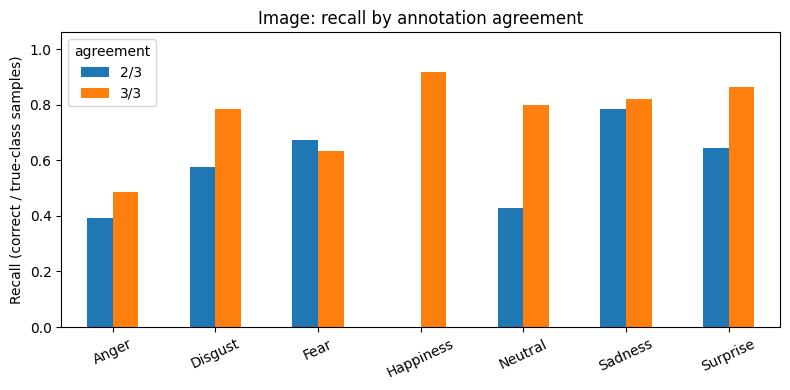

FEA: per-class recall


agreement,2/3,3/3,delta_3_minus_2_pp
category,,,
Anger,0.3571,0.5750,21.7857
Disgust,0.5769,0.5714,-0.5495
Fear,0.6000,0.5789,-2.1053
Happiness,NaN,1.0000,NaN
Neutral,1.0000,0.9149,-8.5106
Sadness,0.8571,0.9149,5.7751
Surprise,1.0000,0.9500,-5.0000


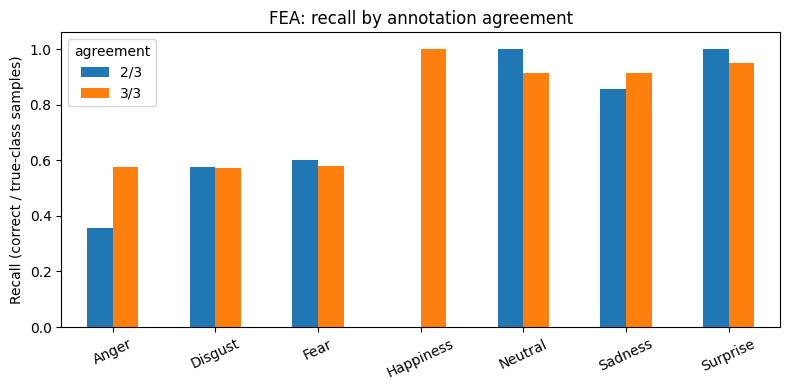

Multimodal: per-class recall


agreement,2/3,3/3,delta_3_minus_2_pp
category,,,
Anger,0.3929,0.6125,21.9643
Disgust,0.5962,0.7321,13.5989
Fear,0.8429,0.7632,-7.9699
Happiness,NaN,1.0000,NaN
Neutral,0.9286,0.9468,1.8237
Sadness,0.8571,0.9362,7.9027
Surprise,0.6429,0.8625,21.9643


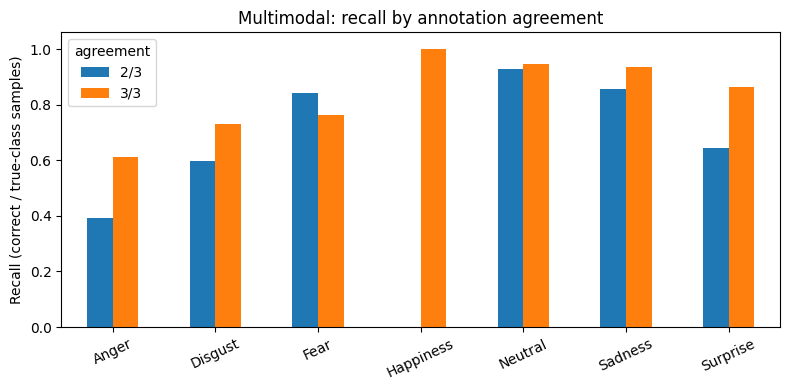

In [6]:
overall_rows = []
per_class_parts = []
standardized_rows = []
common_labels_by_modality = {}

for modality, spec in MODEL_SPECS.items():
    frame = MODEL_FRAMES[modality]
    pred_col = spec["pred_col"]
    modality_per_class = []

    for agreement_group in ["2/3", "3/3"]:
        subset = frame.loc[frame.agreement_group.eq(agreement_group)]
        overall_rows.append(
            {"modality": modality, "agreement": agreement_group, **metrics(cm_of(subset, pred_col))}
        )

        pc = per_class_metrics(subset, pred_col, modality, agreement_group)
        modality_per_class.append(pc)
        per_class_parts.append(pc)

    modality_pc = pd.concat(modality_per_class, ignore_index=True)
    recall_pivot = (
        modality_pc.pivot(index="category", columns="agreement", values="recall")
        .reindex(CATEGORIES)
    )
    common_classes = recall_pivot.dropna().index.tolist()
    common_labels_by_modality[modality] = common_classes

    equal_class = recall_pivot.loc[common_classes, ["2/3", "3/3"]].mean()
    standardized_rows.append(
        {
            "modality": modality,
            "shared_classes": len(common_classes),
            "classes": " | ".join(common_classes),
            "accuracy_2_of_3": equal_class["2/3"],
            "accuracy_3_of_3": equal_class["3/3"],
            "difference_3_minus_2_pp": 100 * (equal_class["3/3"] - equal_class["2/3"]),
        }
    )

overall = pd.DataFrame(overall_rows)
per_class = pd.concat(per_class_parts, ignore_index=True)
class_standardized = pd.DataFrame(standardized_rows)

# Macro F1 over the labels that are present in both agreement groups.
for modality, common_classes in common_labels_by_modality.items():
    common_idx = [CATEGORIES.index(category) for category in common_classes]

    for agreement_group in ["2/3", "3/3"]:
        frame = MODEL_FRAMES[modality].loc[
            MODEL_FRAMES[modality].agreement_group.eq(agreement_group)
        ]
        cm = cm_of(frame, MODEL_SPECS[modality]["pred_col"])
        denominator = cm.sum(axis=0) + cm.sum(axis=1)
        f1 = np.divide(
            2 * np.diag(cm),
            denominator,
            out=np.zeros(len(CATEGORIES)),
            where=denominator > 0,
        )

        mask = overall.modality.eq(modality) & overall.agreement.eq(agreement_group)
        overall.loc[mask, "macro_f1_common_labels"] = f1[common_idx].mean()

overall.to_csv(OUTPUT_DIR / "overall_metrics_by_modality_and_agreement.csv", index=False)
per_class.to_csv(OUTPUT_DIR / "per_class_metrics_by_modality_and_agreement.csv", index=False)
class_standardized.to_csv(
    OUTPUT_DIR / "class_standardized_accuracy_by_modality.csv", index=False
)

display(overall)
display(class_standardized)

for modality in MODEL_SPECS:
    print(f"{modality}: per-class recall")

    recall_table = (
        per_class.loc[per_class.modality.eq(modality)]
        .pivot(index="category", columns="agreement", values="recall")
        .reindex(CATEGORIES)
    )
    recall_table["delta_3_minus_2_pp"] = 100 * (
        recall_table["3/3"] - recall_table["2/3"]
    )

    display(recall_table)
    recall_table.to_csv(OUTPUT_DIR / f"{modality.lower()}_per_class_recall_contrasts.csv")

    fig, ax = plt.subplots(figsize=(8, 4))
    recall_table[["2/3", "3/3"]].plot.bar(ax=ax)
    ax.set(
        ylabel="Recall (correct / true-class samples)",
        xlabel="",
        ylim=(0, 1.06),
        title=f"{modality}: recall by annotation agreement",
    )
    ax.tick_params(axis="x", rotation=25)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{modality.lower()}_recall_by_class.png", dpi=180)
    plt.show()


## 6. Class-level human agreement versus recognition difficulty

This table directly addresses whether the class ranking observed by the models mirrors annotation ambiguity.

For each expression category it combines:

- the 3/3 agreement rate across all 1,727 retained SFEA/DFEA reenactments;
- the 3/3 agreement rate in the held-out test split;
- overall test recall for Image, FEA, and Multimodal models.

Image and Multimodal recall use both views, matching the primary dynamic evaluation. FEA recall uses one prediction per reenactment.

Pearson and Spearman correlations across the seven classes are reported only as **descriptive summaries**. With seven categories, they are not treated as inferential evidence.


,category,all_dataset_n,all_dataset_percent_3_of_3,test_reenactments,test_percent_3_of_3,image_recall,fea_recall,multimodal_recall
0,Anger,175,56.5714,54,74.0741,0.4630,0.5185,0.5556
1,Disgust,211,54.9763,54,51.8519,0.6852,0.5741,0.6667
2,Fear,214,39.7196,54,35.1852,0.6574,0.5926,0.8148
3,Happiness,300,97.0000,54,100.0000,0.9167,1.0000,1.0000
4,Neutral,306,87.9085,54,87.0370,0.7500,0.9259,0.9444
5,Sadness,240,74.1667,54,87.0370,0.8148,0.9074,0.9259
6,Surprise,281,72.9537,54,74.0741,0.8056,0.9630,0.8056


,modality,agreement_scope,n_classes,pearson_r,spearman_rho
0,Image,all retained splits,7,0.7131,0.7857
1,Image,test split,7,0.5125,0.7638
2,FEA,all retained splits,7,0.8704,0.7500
3,FEA,test split,7,0.7491,0.6547
4,Multimodal,all retained splits,7,0.7050,0.7500
5,Multimodal,test split,7,0.5244,0.7092


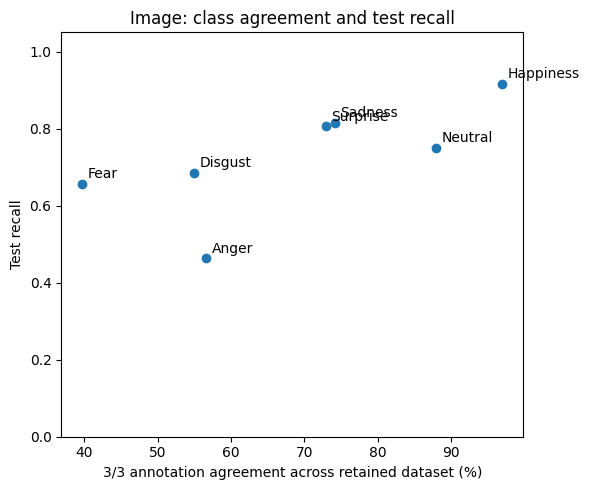

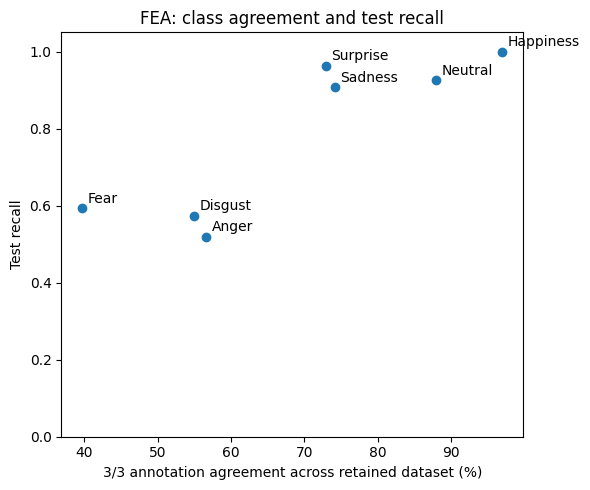

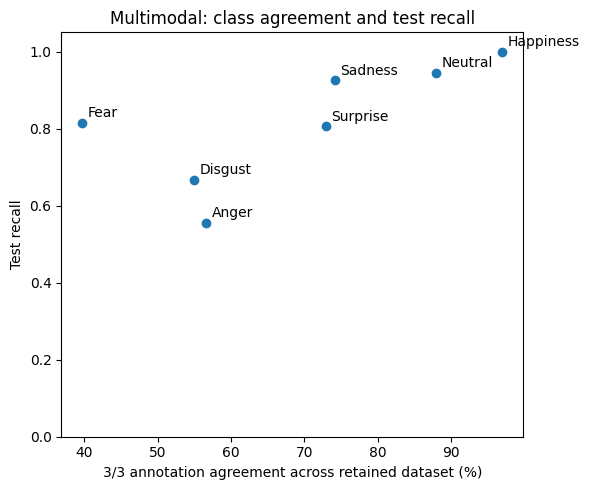

In [7]:
all_class_agreement = (
    all_agreement.drop(index="Total")
    .loc[CATEGORIES, ["n_total", "percent_3_of_3"]]
    .rename(
        columns={
            "n_total": "all_dataset_n",
            "percent_3_of_3": "all_dataset_percent_3_of_3",
        }
    )
)

test_class_agreement = (
    split_agreement.loc["test"]
    .drop(index="Total")
    .loc[CATEGORIES, ["n_total", "percent_3_of_3"]]
    .rename(
        columns={
            "n_total": "test_reenactments",
            "percent_3_of_3": "test_percent_3_of_3",
        }
    )
)

classwise_model_recall = []
for modality, spec in MODEL_SPECS.items():
    pc = per_class_metrics(
        MODEL_FRAMES[modality], spec["pred_col"], modality, agreement_group="all"
    )
    classwise_model_recall.append(
        pc[["category", "recall"]].rename(
            columns={"recall": f"{modality.lower()}_recall"}
        )
    )

classwise_summary = all_class_agreement.join(test_class_agreement).reset_index()
for recall_frame in classwise_model_recall:
    classwise_summary = classwise_summary.merge(
        recall_frame, on="category", how="left", validate="one_to_one"
    )

classwise_summary.to_csv(
    OUTPUT_DIR / "classwise_agreement_and_model_recall.csv", index=False
)
display(classwise_summary)

correlation_rows = []
for modality in MODEL_SPECS:
    recall_col = f"{modality.lower()}_recall"

    for agreement_col, scope in [
        ("all_dataset_percent_3_of_3", "all retained splits"),
        ("test_percent_3_of_3", "test split"),
    ]:
        pair = classwise_summary[[agreement_col, recall_col]].dropna()
        correlation_rows.append(
            {
                "modality": modality,
                "agreement_scope": scope,
                "n_classes": len(pair),
                "pearson_r": pair[agreement_col].corr(pair[recall_col], method="pearson"),
                "spearman_rho": pair[agreement_col].corr(
                    pair[recall_col], method="spearman"
                ),
            }
        )

classwise_correlations = pd.DataFrame(correlation_rows)
classwise_correlations.to_csv(
    OUTPUT_DIR / "classwise_agreement_recall_correlations.csv", index=False
)
display(classwise_correlations)

for modality in MODEL_SPECS:
    y_col = f"{modality.lower()}_recall"

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(classwise_summary["all_dataset_percent_3_of_3"], classwise_summary[y_col])

    for _, row in classwise_summary.iterrows():
        ax.annotate(
            row["category"],
            (row["all_dataset_percent_3_of_3"], row[y_col]),
            xytext=(4, 4),
            textcoords="offset points",
        )

    ax.set(
        xlabel="3/3 annotation agreement across retained dataset (%)",
        ylabel="Test recall",
        ylim=(0, 1.05),
        title=f"{modality}: class agreement and test recall",
    )
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{modality.lower()}_class_agreement_vs_recall.png", dpi=180)
    plt.show()


## 7. Directed errors and their denominators

For every modality and every directed confusion A→B, the notebook reports the error count and the rate among **all true-A samples in that agreement group**.

For Image and Multimodal models these are view-level rates. For FEA they are reenactment-level rates.

The share of 2/3 annotations among errors is compared with the 2/3 share in the source class so that frequent errors are not confused with overrepresentation caused by unequal agreement-group sizes.


In [8]:
directed_rows = []

for modality, spec in MODEL_SPECS.items():
    frame = MODEL_FRAMES[modality]
    pred_col = spec["pred_col"]
    minority_col = f"{modality.lower()}_minority_match"

    for source in CATEGORIES:
        for target in CATEGORIES:
            if source == target:
                continue

            row = {"modality": modality, "source": source, "target": target}

            for agreement in [2, 3]:
                subset = frame.loc[
                    frame.true_label.eq(source) & frame.agreement.eq(agreement)
                ]
                count = int(subset[pred_col].eq(target).sum())

                row[f"n_{agreement}"] = len(subset)
                row[f"errors_{agreement}"] = count
                row[f"rate_{agreement}"] = count / len(subset) if len(subset) else np.nan

            row["total_errors"] = row["errors_2"] + row["errors_3"]
            row["rate_delta_2_minus_3_pp"] = 100 * (row["rate_2"] - row["rate_3"])
            row["two_vote_share_in_errors"] = (
                row["errors_2"] / row["total_errors"] if row["total_errors"] else np.nan
            )
            row["two_vote_share_in_source"] = row["n_2"] / (row["n_2"] + row["n_3"])

            cases = frame.loc[
                frame.true_label.eq(source)
                & frame[pred_col].eq(target)
                & frame.agreement.eq(2)
            ]

            row["minority_matches"] = int(cases[minority_col].sum())
            row["minority_match_rate_among_two_vote_errors"] = (
                cases[minority_col].mean() if len(cases) else np.nan
            )
            row["error_participants"] = frame.loc[
                frame.true_label.eq(source) & frame[pred_col].eq(target),
                "participant_id",
            ].nunique()

            directed_rows.append(row)

directed = pd.DataFrame(directed_rows).sort_values(
    ["modality", "total_errors"], ascending=[True, False]
)
directed.to_csv(
    OUTPUT_DIR / "all_directed_confusions_by_modality_and_agreement.csv", index=False
)

for modality in MODEL_SPECS:
    print(f"{modality}: observed directed errors")
    display(directed.loc[directed.modality.eq(modality) & directed.total_errors.gt(0)])


Image: observed directed errors


,modality,source,target,n_2,errors_2,rate_2,n_3,errors_3,rate_3,total_errors,rate_delta_2_minus_3_pp,two_vote_share_in_errors,two_vote_share_in_source,minority_matches,minority_match_rate_among_two_vote_errors,error_participants
0,Image,Anger,Disgust,28,10,0.3571,80,35,0.4375,45,-8.0357,0.2222,0.2593,8,0.8000,8
38,Image,Surprise,Fear,28,10,0.3571,80,9,0.1125,19,24.4643,0.5263,0.2593,10,1.0000,4
8,Image,Disgust,Happiness,52,9,0.1731,56,9,0.1607,18,1.2363,0.5000,0.4815,4,0.4444,4
13,Image,Fear,Disgust,70,7,0.1000,38,11,0.2895,18,-18.9474,0.3889,0.6481,1,0.1429,5
30,Image,Sadness,Anger,14,1,0.0714,94,14,0.1489,15,-7.7508,0.0667,0.1296,1,1.0000,5
24,Image,Neutral,Anger,14,4,0.2857,94,8,0.0851,12,20.0608,0.3333,0.1296,0,0.0000,3
28,Image,Neutral,Sadness,14,0,0.0000,94,10,0.1064,10,-10.6383,0.0000,0.1296,0,NaN,2
6,Image,Disgust,Anger,52,8,0.1538,56,0,0.0000,8,15.3846,1.0000,0.4815,5,0.6250,4
14,Image,Fear,Happiness,70,6,0.0857,38,2,0.0526,8,3.3083,0.7500,0.6481,0,0.0000,3
17,Image,Fear,Surprise,70,7,0.1000,38,0,0.0000,7,10.0000,1.0000,0.6481,7,1.0000,2


FEA: observed directed errors


,modality,source,target,n_2,errors_2,rate_2,n_3,errors_3,rate_3,total_errors,rate_delta_2_minus_3_pp,two_vote_share_in_errors,two_vote_share_in_source,minority_matches,minority_match_rate_among_two_vote_errors,error_participants
42,FEA,Anger,Disgust,14,8,0.5714,40,15,0.3750,23,19.6429,0.3478,0.2593,7,0.8750,5
50,FEA,Disgust,Happiness,26,4,0.1538,28,6,0.2143,10,-6.0440,0.4000,0.4815,3,0.7500,3
59,FEA,Fear,Surprise,35,8,0.2286,19,1,0.0526,9,17.5940,0.8889,0.6481,6,0.7500,3
49,FEA,Disgust,Fear,26,4,0.1538,28,3,0.1071,7,4.6703,0.5714,0.4815,4,1.0000,2
57,FEA,Fear,Neutral,35,3,0.0857,19,3,0.1579,6,-7.2180,0.5000,0.6481,0,0.0000,3
56,FEA,Fear,Happiness,35,1,0.0286,19,3,0.1579,4,-12.9323,0.2500,0.6481,0,0.0000,2
73,FEA,Sadness,Disgust,7,1,0.1429,47,3,0.0638,4,7.9027,0.2500,0.1296,0,0.0000,1
55,FEA,Fear,Disgust,35,2,0.0571,19,1,0.0526,3,0.4511,0.6667,0.6481,2,1.0000,2
69,FEA,Neutral,Happiness,7,0,0.0000,47,3,0.0638,3,-6.3830,0.0000,0.1296,0,NaN,2
45,FEA,Anger,Neutral,14,1,0.0714,40,1,0.0250,2,4.6429,0.5000,0.2593,1,1.0000,1


Multimodal: observed directed errors


,modality,source,target,n_2,errors_2,rate_2,n_3,errors_3,rate_3,total_errors,rate_delta_2_minus_3_pp,two_vote_share_in_errors,two_vote_share_in_source,minority_matches,minority_match_rate_among_two_vote_errors,error_participants
84,Multimodal,Anger,Disgust,28,15,0.5357,80,29,0.3625,44,17.3214,0.3409,0.2593,13,0.8667,7
92,Multimodal,Disgust,Happiness,52,8,0.1538,56,12,0.2143,20,-6.0440,0.4000,0.4815,6,0.7500,3
122,Multimodal,Surprise,Fear,28,10,0.3571,80,10,0.1250,20,23.2143,0.5000,0.2593,10,1.0000,5
98,Multimodal,Fear,Happiness,70,4,0.0571,38,6,0.1579,10,-10.0752,0.4000,0.6481,0,0.0000,3
90,Multimodal,Disgust,Anger,52,8,0.1538,56,0,0.0000,8,15.3846,1.0000,0.4815,5,0.6250,4
115,Multimodal,Sadness,Disgust,14,1,0.0714,94,6,0.0638,7,0.7599,0.1429,0.1296,0,0.0000,1
91,Multimodal,Disgust,Fear,52,3,0.0577,56,2,0.0357,5,2.1978,0.6000,0.4815,3,1.0000,1
87,Multimodal,Anger,Neutral,28,2,0.0714,80,2,0.0250,4,4.6429,0.5000,0.2593,2,1.0000,1
97,Multimodal,Fear,Disgust,70,3,0.0429,38,1,0.0263,4,1.6541,0.7500,0.6481,2,0.6667,2
101,Multimodal,Fear,Surprise,70,4,0.0571,38,0,0.0000,4,5.7143,1.0000,0.6481,4,1.0000,1


## 8. Confusion matrices by agreement level

Each figure uses true-class row normalization while displaying raw cell counts.

Image and Multimodal matrices count views; FEA matrices count reenactments.


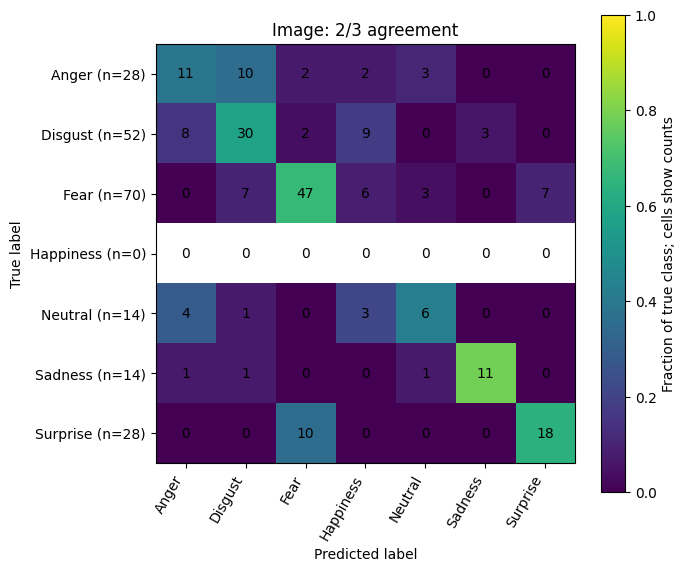

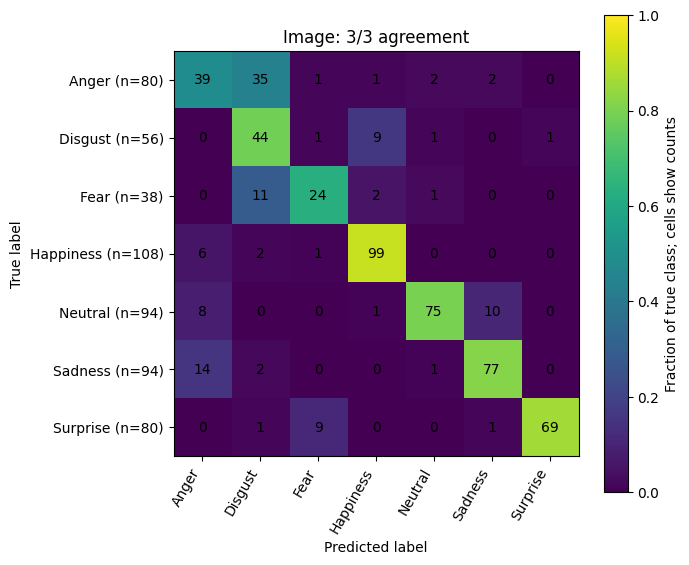

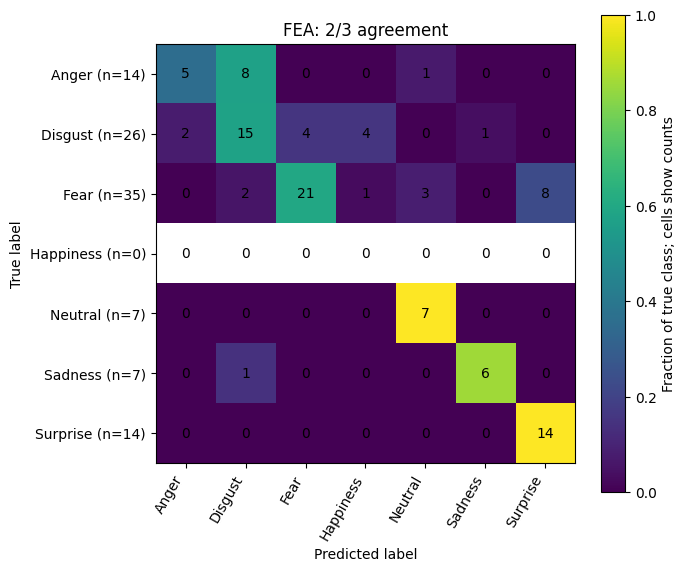

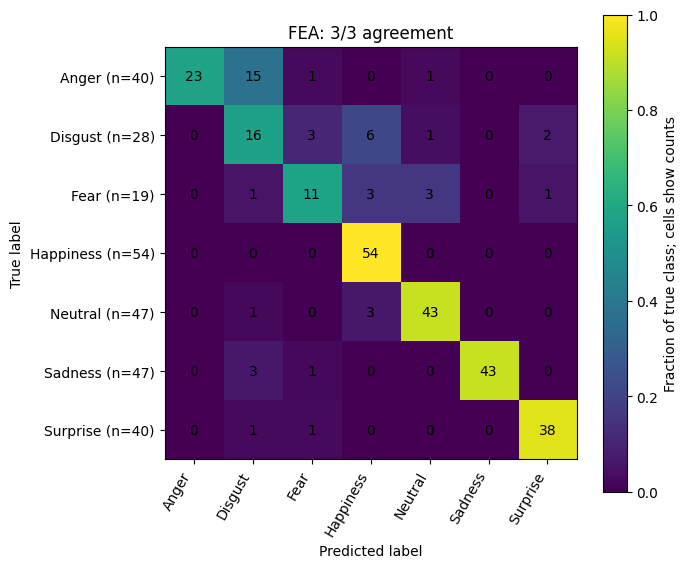

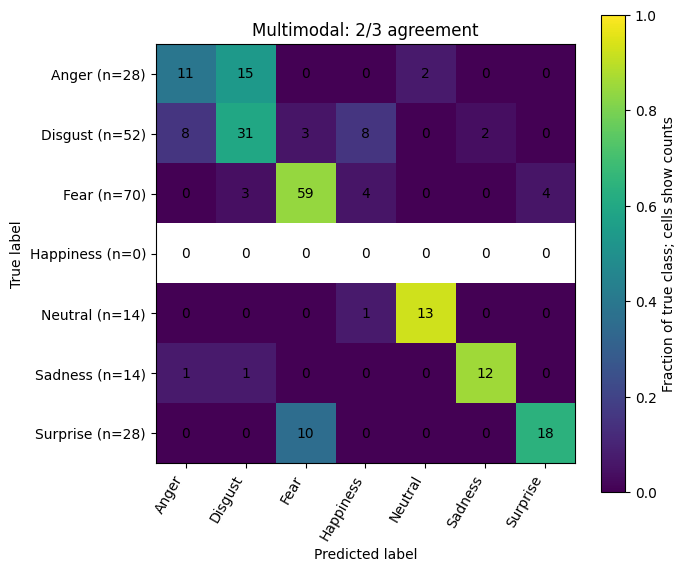

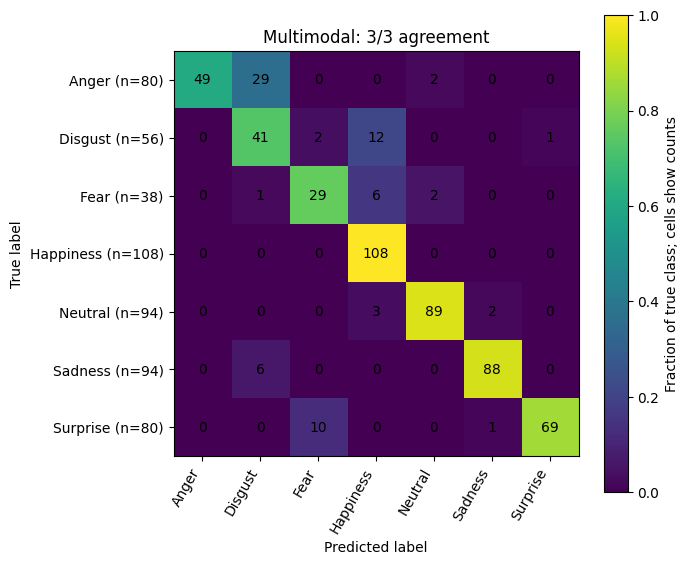

In [9]:
for modality, spec in MODEL_SPECS.items():
    frame = MODEL_FRAMES[modality]
    pred_col = spec["pred_col"]

    for agreement in [2, 3]:
        subset = frame.loc[frame.agreement.eq(agreement)]
        cm = cm_of(subset, pred_col)

        denominator = cm.sum(axis=1, keepdims=True)
        rates = np.divide(
            cm,
            denominator,
            out=np.full(cm.shape, np.nan, dtype=float),
            where=denominator > 0,
        )

        fig, ax = plt.subplots(figsize=(7, 6))
        image = ax.imshow(rates, vmin=0, vmax=1)

        for i in range(len(CATEGORIES)):
            for j in range(len(CATEGORIES)):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")

        ax.set_xticks(range(len(CATEGORIES)), CATEGORIES, rotation=60, ha="right")
        ax.set_yticks(
            range(len(CATEGORIES)),
            [
                f"{category} (n={int(denominator[i, 0])})"
                for i, category in enumerate(CATEGORIES)
            ],
        )
        ax.set(
            title=f"{modality}: {agreement}/3 agreement",
            xlabel="Predicted label",
            ylabel="True label",
        )
        fig.colorbar(image, ax=ax, label="Fraction of true class; cells show counts")
        fig.tight_layout()
        fig.savefig(
            OUTPUT_DIR / f"{modality.lower()}_confusion_{agreement}_of_3.png", dpi=180
        )
        plt.show()


## 9. Does a model error match the dissenting rater?

For 2/3 cases the prediction is classified as:

- the majority/retained label;
- the dissenting label;
- neither.

The primary quantity is the **minority-label match rate among model errors**.

The descriptive shuffle benchmark preserves the reenactment structure. Dissenting labels are shuffled among unique reenactments within the same true class and then mapped back to both view rows for Image and Multimodal models. This avoids treating the two views as independent annotation cases.

The benchmark is descriptive; no permutation p-value is claimed.


In [10]:
def minority_correspondence(modality, frame, pred_col):
    correct_col = f"{modality.lower()}_correct"
    minority_col = f"{modality.lower()}_minority_match"

    two = frame.loc[frame.agreement.eq(2)].copy()
    two["prediction_relation"] = np.select(
        [two[correct_col], two[minority_col]],
        ["majority label", "dissenting label"],
        default="neither",
    )

    relation = pd.crosstab(two.true_label, two.prediction_relation).reindex(
        index=CATEGORIES,
        columns=["majority label", "dissenting label", "neither"],
        fill_value=0,
    )
    relation["total"] = relation.sum(axis=1)
    relation["minority_match_among_errors"] = relation["dissenting label"] / (
        relation["dissenting label"] + relation["neither"]
    ).replace(0, np.nan)
    relation.insert(0, "modality", modality)

    minority_errors = two.loc[~two[correct_col]]
    observed_match = (
        minority_errors[minority_col].mean() if len(minority_errors) else np.nan
    )

    # Shuffle dissent labels at reenactment level, then map them back to view rows.
    unique_two = two[
        ["reenactment_id", "true_label", "minority_label"]
    ].drop_duplicates("reenactment_id")

    rng = np.random.default_rng(SEED)
    null_matches = []

    for _ in range(N_BOOT):
        shuffled_map = {}

        for _, group in unique_two.groupby("true_label"):
            ids = group["reenactment_id"].to_numpy()
            shuffled_labels = rng.permutation(group["minority_label"].to_numpy())
            shuffled_map.update(dict(zip(ids, shuffled_labels)))

        shuffled = two["reenactment_id"].map(shuffled_map)
        error_mask = ~two[correct_col]
        matched = (two[pred_col].eq(shuffled) & error_mask).sum()
        null_matches.append(matched / error_mask.sum() if error_mask.sum() else np.nan)

    benchmark = pd.DataFrame(
        [
            {
                "modality": modality,
                "analysis_unit": MODEL_SPECS[modality]["unit"],
                "two_vote_rows": len(two),
                "two_vote_reenactments": two["reenactment_id"].nunique(),
                "two_vote_errors": len(minority_errors),
                "minority_matches": int(minority_errors[minority_col].sum()),
                "observed_match_rate_among_errors": observed_match,
                "class_conditioned_shuffle_mean": np.nanmean(null_matches),
                "shuffle_q025": np.nanquantile(null_matches, 0.025),
                "shuffle_q975": np.nanquantile(null_matches, 0.975),
            }
        ]
    )

    return relation, benchmark


relation_parts = []
benchmark_parts = []

for modality, spec in MODEL_SPECS.items():
    relation, benchmark = minority_correspondence(
        modality, MODEL_FRAMES[modality], spec["pred_col"]
    )
    relation_parts.append(relation.reset_index())
    benchmark_parts.append(benchmark)

minority_relation = pd.concat(relation_parts, ignore_index=True)
minority_benchmark = pd.concat(benchmark_parts, ignore_index=True)

minority_relation.to_csv(
    OUTPUT_DIR / "minority_label_correspondence_by_modality.csv", index=False
)
minority_benchmark.to_csv(
    OUTPUT_DIR / "minority_match_descriptive_benchmark_by_modality.csv", index=False
)

display(minority_relation)
display(minority_benchmark)


prediction_relation,true_label,modality,majority label,dissenting label,neither,total,minority_match_among_errors
0,Anger,Image,11,10,7,28,0.5882
1,Disgust,Image,30,12,10,52,0.5455
2,Fear,Image,47,8,15,70,0.3478
3,Happiness,Image,0,0,0,0,NaN
4,Neutral,Image,6,3,5,14,0.3750
5,Sadness,Image,11,1,2,14,0.3333
6,Surprise,Image,18,10,0,28,1.0000
7,Anger,FEA,5,8,1,14,0.8889
8,Disgust,FEA,15,10,1,26,0.9091
9,Fear,FEA,21,8,6,35,0.5714


,modality,analysis_unit,two_vote_rows,two_vote_reenactments,two_vote_errors,minority_matches,observed_match_rate_among_errors,class_conditioned_shuffle_mean,shuffle_q025,shuffle_q975
0,Image,view,206,103,83,44,0.5301,0.3905,0.3133,0.4699
1,FEA,reenactment,103,103,35,26,0.7429,0.4498,0.3143,0.5714
2,Multimodal,view,206,103,62,49,0.7903,0.5009,0.4032,0.6129


## 10. Central-versus-Side sensitivity for Image and Multimodal models

The primary Image and Multimodal analyses above use both views because that matches the reported dynamic evaluation.

This section checks whether the association with annotation agreement depends strongly on view perspective.

Note that the human agreement score itself comes from the selected **central-view reference image**, so the side-view analysis tests whether ambiguity measured from that reference image also relates to recognition from the second view.


In [11]:
view_summary_rows = []
view_per_class_rows = []

for modality in ["Image", "Multimodal"]:
    pred_col = MODEL_SPECS[modality]["pred_col"]

    for perspective in ["Central", "Side"]:
        frame = view_data.loc[view_data.perspective.eq(perspective)]
        assert len(frame) == 378
        assert frame.reenactment_id.nunique() == 378

        for agreement_group in ["2/3", "3/3"]:
            subset = frame.loc[frame.agreement_group.eq(agreement_group)]
            view_summary_rows.append(
                {
                    "modality": modality,
                    "perspective": perspective,
                    "agreement": agreement_group,
                    **metrics(cm_of(subset, pred_col)),
                }
            )

            pc = per_class_metrics(subset, pred_col, modality, agreement_group)
            pc["perspective"] = perspective
            view_per_class_rows.append(pc)

        _, benchmark = minority_correspondence(modality, frame, pred_col)
        benchmark["perspective"] = perspective

        for _, row in benchmark.iterrows():
            view_summary_rows.append(
                {
                    "modality": modality,
                    "perspective": perspective,
                    "agreement": "2/3 errors",
                    "n": row["two_vote_errors"],
                    "accuracy": np.nan,
                    "macro_f1": np.nan,
                    "weighted_f1": np.nan,
                    "classes_with_support": np.nan,
                    "minority_match_rate_among_errors": row[
                        "observed_match_rate_among_errors"
                    ],
                }
            )

view_sensitivity = pd.DataFrame(view_summary_rows)
view_per_class = pd.concat(view_per_class_rows, ignore_index=True)

view_sensitivity.to_csv(
    OUTPUT_DIR / "image_multimodal_view_sensitivity_summary.csv", index=False
)
view_per_class.to_csv(
    OUTPUT_DIR / "image_multimodal_view_specific_per_class_metrics.csv", index=False
)

display(view_sensitivity)


,modality,perspective,agreement,n,accuracy,macro_f1,weighted_f1,classes_with_support,minority_match_rate_among_errors
0,Image,Central,2/3,103,0.5922,0.5137,0.6164,6.0000,NaN
1,Image,Central,3/3,275,0.7818,0.7537,0.7865,7.0000,NaN
2,Image,Central,2/3 errors,42,NaN,NaN,NaN,NaN,0.4762
3,Image,Side,2/3,103,0.6019,0.5286,0.6386,6.0000,NaN
4,Image,Side,3/3,275,0.7709,0.7543,0.7778,7.0000,NaN
5,Image,Side,2/3 errors,41,NaN,NaN,NaN,NaN,0.5854
6,Multimodal,Central,2/3,103,0.6990,0.6271,0.7132,6.0000,NaN
7,Multimodal,Central,3/3,275,0.8618,0.8396,0.8634,7.0000,NaN
8,Multimodal,Central,2/3 errors,31,NaN,NaN,NaN,NaN,0.7742
9,Multimodal,Side,2/3,103,0.6990,0.6208,0.7163,6.0000,NaN


## 11. Participant and Participant × Class sensitivity

For every modality:

1. compare 3/3 and 2/3 performance within each participant;
2. compare them within Participant × True Class cells;
3. give equal weight to each shared cell when summarizing the latter contrast.

The Participant × Class analysis targets a restricted population containing only cells with both agreement levels. It is not a causal adjustment.


In [12]:
participant_tables = []
participant_class_tables = []
participant_class_summary_rows = []

for modality in MODEL_SPECS:
    frame = MODEL_FRAMES[modality]
    correct_col = f"{modality.lower()}_correct"

    participant = (
        frame.groupby(["participant_id", "agreement_group"])[correct_col]
        .agg(["size", "mean"])
        .unstack("agreement_group")
    )
    participant["contrast", "3_minus_2_pp"] = 100 * (
        participant["mean", "3/3"] - participant["mean", "2/3"]
    )

    participant_flat = participant.copy()
    participant_flat.columns = [
        "_".join(str(value) for value in column if str(value))
        for column in participant_flat.columns
    ]
    participant_flat = participant_flat.reset_index()
    participant_flat.insert(0, "modality", modality)
    participant_tables.append(participant_flat)

    pc = (
        frame.groupby(["participant_id", "true_label", "agreement_group"])[correct_col]
        .agg(["size", "mean"])
        .unstack("agreement_group")
    )
    shared_pc = pc.dropna(subset=[("mean", "2/3"), ("mean", "3/3")]).copy()
    shared_pc["contrast", "3_minus_2_pp"] = 100 * (
        shared_pc["mean", "3/3"] - shared_pc["mean", "2/3"]
    )

    shared_flat = shared_pc.copy()
    shared_flat.columns = [
        "_".join(str(value) for value in column if str(value))
        for column in shared_flat.columns
    ]
    shared_flat = shared_flat.reset_index()
    shared_flat.insert(0, "modality", modality)
    participant_class_tables.append(shared_flat)

    participant_class_summary_rows.append(
        {
            "modality": modality,
            "shared_participant_class_cells": len(shared_pc),
            "participants_represented": shared_pc.index.get_level_values(0).nunique(),
            "mean_equal_cell_difference_3_minus_2_pp": shared_pc[
                "contrast", "3_minus_2_pp"
            ].mean(),
        }
    )

participant_accuracy = pd.concat(participant_tables, ignore_index=True)
shared_participant_class = pd.concat(participant_class_tables, ignore_index=True)
participant_class_summary = pd.DataFrame(participant_class_summary_rows)

participant_accuracy.to_csv(
    OUTPUT_DIR / "participant_accuracy_by_modality.csv", index=False
)
shared_participant_class.to_csv(
    OUTPUT_DIR / "shared_participant_class_accuracy_by_modality.csv", index=False
)
participant_class_summary.to_csv(
    OUTPUT_DIR / "participant_class_sensitivity_summary.csv", index=False
)

display(participant_class_summary)


,modality,shared_participant_class_cells,participants_represented,mean_equal_cell_difference_3_minus_2_pp
0,Image,32,8,16.2463
1,FEA,32,8,-1.5848
2,Multimodal,32,8,13.2478


## 12. Participant-cluster bootstrap and leave-one-participant-out sensitivity

Whole participants are resampled with replacement. All reenactments and, for Image/Multimodal, both view rows of a participant remain together.

This preserves the central/side dependence inside a participant cluster. Only eight test participants are available, so percentile intervals are exploratory and may be unstable.

No view-level independence is assumed.


In [13]:
pids = sorted(fea_data.participant_id.unique())
assert set(pids) == set(view_data.participant_id.unique())

rng = np.random.default_rng(SEED)
bootstrap_indices = [
    rng.integers(0, len(pids), len(pids))
    for _ in range(N_BOOT)
]


def contrast(cms, common_idx):
    group_metrics = [metrics(cm) for cm in cms]
    a, b = group_metrics
    out = {
        key: b[key] - a[key]
        for key in ["accuracy", "macro_f1", "weighted_f1"]
    }

    f1s = []
    for cm in cms:
        denominator = cm.sum(axis=0) + cm.sum(axis=1)
        f1 = np.divide(
            2 * np.diag(cm),
            denominator,
            out=np.zeros(len(CATEGORIES)),
            where=denominator > 0,
        )
        f1s.append(f1[common_idx].mean())

    out["macro_f1_common_labels"] = f1s[1] - f1s[0]

    supports = cms.sum(axis=2)
    if common_idx and (supports[:, common_idx] > 0).all():
        recalls = np.stack([np.diag(cm) for cm in cms]) / np.where(
            supports > 0, supports, np.nan
        )
        out["class_standardized_accuracy"] = (
            recalls[1, common_idx] - recalls[0, common_idx]
        ).mean()
    else:
        out["class_standardized_accuracy"] = np.nan

    return out


interval_parts = []
loo_parts = []

for modality, spec in MODEL_SPECS.items():
    frame = MODEL_FRAMES[modality]
    pred_col = spec["pred_col"]
    common_idx = [
        CATEGORIES.index(category)
        for category in common_labels_by_modality[modality]
    ]

    cluster_cms = np.array(
        [
            [
                cm_of(
                    frame.loc[
                        frame.participant_id.eq(pid) & frame.agreement.eq(agreement)
                    ],
                    pred_col,
                )
                for agreement in [2, 3]
            ]
            for pid in pids
        ]
    )

    point = contrast(cluster_cms.sum(axis=0), common_idx)

    boot = pd.DataFrame(
        [
            contrast(cluster_cms[indices].sum(axis=0), common_idx)
            for indices in bootstrap_indices
        ]
    )

    intervals = pd.DataFrame(
        [
            {
                "modality": modality,
                "metric": key,
                "difference_3_minus_2": value,
                "ci025": boot[key].quantile(0.025),
                "ci975": boot[key].quantile(0.975),
                "valid_bootstrap_draws": boot[key].notna().sum(),
            }
            for key, value in point.items()
        ]
    )

    loo = pd.DataFrame(
        [
            {
                "modality": modality,
                "omitted_participant": pid,
                **contrast(np.delete(cluster_cms, i, axis=0).sum(axis=0), common_idx),
            }
            for i, pid in enumerate(pids)
        ]
    )

    interval_parts.append(intervals)
    loo_parts.append(loo)

bootstrap_intervals = pd.concat(interval_parts, ignore_index=True)
leave_one_out = pd.concat(loo_parts, ignore_index=True)

bootstrap_intervals.to_csv(
    OUTPUT_DIR / "participant_cluster_bootstrap_by_modality.csv", index=False
)
leave_one_out.to_csv(
    OUTPUT_DIR / "leave_one_participant_out_by_modality.csv", index=False
)

display(bootstrap_intervals)


,modality,metric,difference_3_minus_2,ci025,ci975,valid_bootstrap_draws
0,Image,accuracy,0.1793,-0.0385,0.3882,2000
1,Image,macro_f1,0.2339,0.1115,0.3872,2000
2,Image,weighted_f1,0.1550,-0.0610,0.3453,2000
3,Image,macro_f1_common_labels,0.1228,-0.0104,0.2957,2000
4,Image,class_standardized_accuracy,0.1477,-0.0220,0.3217,1955
5,FEA,accuracy,0.1689,-0.0029,0.3587,2000
6,FEA,macro_f1,0.1953,0.0987,0.3308,2000
7,FEA,weighted_f1,0.1647,-0.0147,0.3605,2000
8,FEA,macro_f1_common_labels,0.0778,-0.0383,0.2347,2000
9,FEA,class_standardized_accuracy,0.0190,-0.0627,0.0979,1955


## 13. Main findings and reproducible summary report

The report below combines the quantitative output tables with an explicit narrative interpretation of the main findings.

The narrative is generated from the computed tables, so the reported percentages and counts remain synchronized with the analysis if the input data are updated.


In [14]:
def md_table(df):
    def fmt(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.4f}" if np.isfinite(value) else "NA"
        return str(value).replace("|", r"\|")

    header = "| " + " | ".join(map(str, df.columns)) + " |"
    separator = "| " + " | ".join(["---"] * len(df.columns)) + " |"
    rows = [
        "| " + " | ".join(fmt(value) for value in row) + " |"
        for row in df.itertuples(index=False, name=None)
    ]
    return "\n".join([header, separator, *rows])


def get_row(df, **conditions):
    mask = pd.Series(True, index=df.index)
    for column, value in conditions.items():
        mask &= df[column].eq(value)
    result = df.loc[mask]
    assert len(result) == 1, f"Expected one row for {conditions}, found {len(result)}"
    return result.iloc[0]


overall_report = overall[
    [
        "modality", "agreement", "n", "accuracy",
        "macro_f1", "weighted_f1", "macro_f1_common_labels",
    ]
].copy()

class_summary_report = classwise_summary[
    [
        "category", "all_dataset_percent_3_of_3", "test_percent_3_of_3",
        "image_recall", "fea_recall", "multimodal_recall",
    ]
].copy()

benchmark_report = minority_benchmark[
    [
        "modality", "analysis_unit", "two_vote_rows", "two_vote_errors",
        "minority_matches", "observed_match_rate_among_errors",
        "class_conditioned_shuffle_mean", "shuffle_q025", "shuffle_q975",
    ]
].copy()

bootstrap_report = bootstrap_intervals.loc[
    bootstrap_intervals.metric.isin(["accuracy", "class_standardized_accuracy"])
].copy()

view_accuracy_report = view_sensitivity.loc[
    view_sensitivity.agreement.isin(["2/3", "3/3"]),
    ["modality", "perspective", "agreement", "n", "accuracy"],
].copy()

view_minority_report = view_sensitivity.loc[
    view_sensitivity.agreement.eq("2/3 errors"),
    ["modality", "perspective", "n", "minority_match_rate_among_errors"],
].copy()

# Values used in the narrative main findings.
happiness = get_row(classwise_summary, category="Happiness")
anger = get_row(classwise_summary, category="Anger")
disgust = get_row(classwise_summary, category="Disgust")
fear = get_row(classwise_summary, category="Fear")

all_split_corr = classwise_correlations.loc[
    classwise_correlations.agreement_scope.eq("all retained splits")
].set_index("modality")

raw_accuracy = overall.pivot(index="modality", columns="agreement", values="accuracy")
raw_accuracy["difference_pp"] = 100 * (raw_accuracy["3/3"] - raw_accuracy["2/3"])

standardized_lookup = class_standardized.set_index("modality")
minority_lookup = minority_benchmark.set_index("modality")
participant_class_lookup = participant_class_summary.set_index("modality")

view_accuracy_lookup = view_accuracy_report.pivot_table(
    index=["modality", "perspective"], columns="agreement", values="accuracy"
)
view_minority_lookup = view_minority_report.set_index(["modality", "perspective"])

main_findings = f"""## Main findings

### Class-level recognition difficulty broadly mirrors human annotation agreement

The class-level pattern is consistent across all three modalities. **Happiness** has the highest unanimous annotation agreement across the retained dataset (**{happiness['all_dataset_percent_3_of_3']:.1f}% 3/3**) and also shows very high test recall: **{100 * happiness['image_recall']:.1f}% for Image**, **{100 * happiness['fea_recall']:.1f}% for FEA**, and **{100 * happiness['multimodal_recall']:.1f}% for Multimodal FER**.

At the other end, **Fear ({fear['all_dataset_percent_3_of_3']:.1f}% 3/3), Disgust ({disgust['all_dataset_percent_3_of_3']:.1f}%), and Anger ({anger['all_dataset_percent_3_of_3']:.1f}%)** have the lowest unanimous-agreement rates. These categories also tend to be among the more difficult recognition classes, although the relationship is not perfectly monotonic. Fear is the clearest counterexample: despite the lowest annotation agreement, Multimodal recall reaches **{100 * fear['multimodal_recall']:.1f}%**, indicating that multimodal information can partly compensate for a category that is comparatively ambiguous in the human reference-image annotations.

Across the seven categories, the descriptive Pearson correlation between unanimous agreement across all retained splits and test recall is **r = {all_split_corr.loc['Image', 'pearson_r']:.3f} for Image**, **r = {all_split_corr.loc['FEA', 'pearson_r']:.3f} for FEA**, and **r = {all_split_corr.loc['Multimodal', 'pearson_r']:.3f} for Multimodal FER**. The corresponding Spearman correlations are **ρ = {all_split_corr.loc['Image', 'spearman_rho']:.3f}**, **{all_split_corr.loc['FEA', 'spearman_rho']:.3f}**, and **{all_split_corr.loc['Multimodal', 'spearman_rho']:.3f}**. Because these correlations are based on only seven expression categories, they are treated as descriptive summaries rather than inferential evidence.

**References:** `classwise_agreement_and_model_recall.csv`, `classwise_agreement_recall_correlations.csv`, and the three `*_class_agreement_vs_recall.png` figures.

### The raw 2/3-versus-3/3 performance gap is substantial, but class composition matters

Using the primary evaluation units, accuracy rises from **{100 * raw_accuracy.loc['Image', '2/3']:.1f}% to {100 * raw_accuracy.loc['Image', '3/3']:.1f}% for Image FER (+{raw_accuracy.loc['Image', 'difference_pp']:.1f} pp)**, from **{100 * raw_accuracy.loc['FEA', '2/3']:.1f}% to {100 * raw_accuracy.loc['FEA', '3/3']:.1f}% for FEA FER (+{raw_accuracy.loc['FEA', 'difference_pp']:.1f} pp)**, and from **{100 * raw_accuracy.loc['Multimodal', '2/3']:.1f}% to {100 * raw_accuracy.loc['Multimodal', '3/3']:.1f}% for Multimodal FER (+{raw_accuracy.loc['Multimodal', 'difference_pp']:.1f} pp)**.

However, the 2/3 and 3/3 subsets have different class compositions; most notably, Happiness is absent from the 2/3 test subset. After averaging recall equally across the classes represented in both groups, the 3/3-minus-2/3 difference is **{standardized_lookup.loc['Image', 'difference_3_minus_2_pp']:.1f} pp for Image**, only **{standardized_lookup.loc['FEA', 'difference_3_minus_2_pp']:.1f} pp for FEA**, and **{standardized_lookup.loc['Multimodal', 'difference_3_minus_2_pp']:.1f} pp for Multimodal FER**.

The FEA result is particularly important: its raw agreement gap is large, but it almost disappears after equal class weighting. This indicates that much of the raw FEA gap is attributable to **which expression categories occur in the 2/3 and 3/3 subsets**, rather than to a uniform within-category agreement effect. A more substantial class-standardized association remains for Image and Multimodal FER.

**References:** `overall_metrics_by_modality_and_agreement.csv`, `class_standardized_accuracy_by_modality.csv`, and the three `*_per_class_recall_contrasts.csv` tables.

### Errors on ambiguous samples frequently match the dissenting human label

The strongest cross-modal result is the correspondence between model errors and the dissenting rater on 2/3-agreement samples. Among such errors, the predicted category equals the dissenting human label for **{int(minority_lookup.loc['Image', 'minority_matches'])}/{int(minority_lookup.loc['Image', 'two_vote_errors'])} Image errors ({100 * minority_lookup.loc['Image', 'observed_match_rate_among_errors']:.1f}%)**, **{int(minority_lookup.loc['FEA', 'minority_matches'])}/{int(minority_lookup.loc['FEA', 'two_vote_errors'])} FEA errors ({100 * minority_lookup.loc['FEA', 'observed_match_rate_among_errors']:.1f}%)**, and **{int(minority_lookup.loc['Multimodal', 'minority_matches'])}/{int(minority_lookup.loc['Multimodal', 'two_vote_errors'])} Multimodal errors ({100 * minority_lookup.loc['Multimodal', 'observed_match_rate_among_errors']:.1f}%)**.

These observed rates are higher than the corresponding class-conditioned shuffle means of **{100 * minority_lookup.loc['Image', 'class_conditioned_shuffle_mean']:.1f}% for Image**, **{100 * minority_lookup.loc['FEA', 'class_conditioned_shuffle_mean']:.1f}% for FEA**, and **{100 * minority_lookup.loc['Multimodal', 'class_conditioned_shuffle_mean']:.1f}% for Multimodal FER**.

Thus, many errors are not arbitrary alternative categories: they coincide with the **same alternative interpretation chosen by the dissenting human rater**. This supports the interpretation that a substantial subset of model errors occurs on category boundaries that were also ambiguous to human annotators. It does **not** establish that the model prediction or the dissenting annotation is objectively correct, nor does it justify relabeling the benchmark.

**References:** `minority_label_correspondence_by_modality.csv`, `minority_match_descriptive_benchmark_by_modality.csv`, and `all_directed_confusions_by_modality_and_agreement.csv`.

### The Image and Multimodal findings are not driven by one camera perspective

Central and Side views show very similar 2/3-versus-3/3 accuracy patterns. For Image FER, accuracy is **{100 * view_accuracy_lookup.loc[('Image', 'Central'), '2/3']:.1f}% vs. {100 * view_accuracy_lookup.loc[('Image', 'Central'), '3/3']:.1f}%** for Central and **{100 * view_accuracy_lookup.loc[('Image', 'Side'), '2/3']:.1f}% vs. {100 * view_accuracy_lookup.loc[('Image', 'Side'), '3/3']:.1f}%** for Side. For Multimodal FER, the corresponding values are **{100 * view_accuracy_lookup.loc[('Multimodal', 'Central'), '2/3']:.1f}% vs. {100 * view_accuracy_lookup.loc[('Multimodal', 'Central'), '3/3']:.1f}%** for Central and **{100 * view_accuracy_lookup.loc[('Multimodal', 'Side'), '2/3']:.1f}% vs. {100 * view_accuracy_lookup.loc[('Multimodal', 'Side'), '3/3']:.1f}%** for Side.

Minority-label correspondence among 2/3 errors is likewise present in both perspectives: **{100 * view_minority_lookup.loc[('Image', 'Central'), 'minority_match_rate_among_errors']:.1f}% Central vs. {100 * view_minority_lookup.loc[('Image', 'Side'), 'minority_match_rate_among_errors']:.1f}% Side for Image**, and **{100 * view_minority_lookup.loc[('Multimodal', 'Central'), 'minority_match_rate_among_errors']:.1f}% vs. {100 * view_minority_lookup.loc[('Multimodal', 'Side'), 'minority_match_rate_among_errors']:.1f}% for Multimodal FER**.

This supports using both views in the primary Image and Multimodal evaluation rather than interpreting the agreement association as a Central-view-only artifact.

**Reference:** `image_multimodal_view_sensitivity_summary.csv`.

### Participant-level sensitivity reinforces the modality-specific nuance

When Participant × Class cells containing both agreement levels are weighted equally, the mean 3/3-minus-2/3 accuracy contrast is **{participant_class_lookup.loc['Image', 'mean_equal_cell_difference_3_minus_2_pp']:.2f} pp for Image**, **{participant_class_lookup.loc['FEA', 'mean_equal_cell_difference_3_minus_2_pp']:.2f} pp for FEA**, and **{participant_class_lookup.loc['Multimodal', 'mean_equal_cell_difference_3_minus_2_pp']:.2f} pp for Multimodal FER**. This again shows that the FEA agreement contrast is small after conditioning more closely on participant and class, whereas Image and Multimodal retain larger differences.

Participant-cluster bootstrap intervals are reported as an exploratory uncertainty analysis because only {len(pids)} independent test participants are available. They should not be treated as definitive inferential tests.

**References:** `participant_class_sensitivity_summary.csv`, `participant_cluster_bootstrap_by_modality.csv`, and `leave_one_participant_out_by_modality.csv`.

### Overall interpretation

Taken together, the analyses support two complementary conclusions. First, **class-level recognition difficulty broadly mirrors human annotation ambiguity across Image, FEA, and Multimodal FER**, which is consistent with the hardest categories reflecting properties of the underlying expression/category structure rather than a failure confined to one modality. Second, the sample-level 2/3-versus-3/3 association is modality-dependent: it is largely explained by class composition for FEA, while clearer within-class differences remain for Image and Multimodal FER.

The most consistent result across all three modalities is that **errors on 2/3-agreement samples frequently select exactly the dissenting rater's alternative category**. This provides direct descriptive evidence that many model errors coincide with category ambiguity already visible in human perception of the retained reference images.
"""

report = f"""# Annotation agreement and dynamic model errors

## Scope

The analysis compares human annotation agreement with the final dynamic Image, FEA, and Multimodal model predictions on the held-out test set.

Primary evaluation units:

- Image: {len(MODEL_FRAMES['Image'])} view-level predictions from {MODEL_FRAMES['Image'].reenactment_id.nunique()} reenactments.
- FEA: {len(MODEL_FRAMES['FEA'])} reenactment-level predictions.
- Multimodal: {len(MODEL_FRAMES['Multimodal'])} view-level predictions from {MODEL_FRAMES['Multimodal'].reenactment_id.nunique()} reenactments.
- Test participants: {len(pids)}.

The Image and Multimodal view rows are not independent reenactments. Participant-cluster analyses keep both views together.

The three human raters judged one selected central-view reference image. Agreement therefore characterizes perceived category agreement on that image, not objective correctness of the full sequence, side view, or FEA signal.

## Agreement across all retained SFEA/DFEA samples

The independently read SFEA and DFEA memberships match exactly: {len(all_samples)} shared reenactments across train, validation, and test.

{md_table(all_agreement.reset_index())}

Split totals:

{md_table(split_overview.reset_index())}

These counts describe the retained dataset and are independent of model predictions.

## Class-level agreement and model recall

{md_table(class_summary_report)}

Descriptive correlations across the seven classes:

{md_table(classwise_correlations)}

{main_findings}

## Detailed performance tables

### Performance by annotation-agreement group

{md_table(overall_report)}

### Class-standardized accuracy

{md_table(class_standardized)}

### Dissenting-rater correspondence among 2/3 errors

{md_table(benchmark_report)}

### Central-versus-Side sensitivity

Overall accuracy by view and agreement group:

{md_table(view_accuracy_report)}

Minority-label correspondence among 2/3 errors by view:

{md_table(view_minority_report)}

### Participant sensitivity and uncertainty

Participant × Class equal-cell summary:

{md_table(participant_class_summary)}

Participant-cluster bootstrap intervals for accuracy and class-standardized accuracy:

{md_table(bootstrap_report)}

## Interpretation boundaries

- Annotation disagreement is not proof of label error.
- Human ratings concern one central-view reference image, not the full dynamic signal.
- Image and Multimodal pooled-view percentages use 756 view rows, but those rows represent 378 paired reenactments.
- No view-level independence is assumed in participant-cluster uncertainty analyses.
- No labels are changed.
- No model is retrained.
- No new test-set tuning is performed.
- Minority-label correspondence does not establish model correctness.
- Class-level correlations across seven categories are descriptive only.
"""

report_path = OUTPUT_DIR / "label_agreement_and_model_errors_report.md"
report_path.write_text(report, encoding="utf-8")

display(Markdown(report))
print("Saved tables, figures and report to", OUTPUT_DIR.resolve())


# Annotation agreement and dynamic model errors

## Scope

The analysis compares human annotation agreement with the final dynamic Image, FEA, and Multimodal model predictions on the held-out test set.

Primary evaluation units:

- Image: 756 view-level predictions from 378 reenactments.
- FEA: 378 reenactment-level predictions.
- Multimodal: 756 view-level predictions from 378 reenactments.
- Test participants: 8.

The Image and Multimodal view rows are not independent reenactments. Participant-cluster analyses keep both views together.

The three human raters judged one selected central-view reference image. Agreement therefore characterizes perceived category agreement on that image, not objective correctness of the full sequence, side view, or FEA signal.

## Agreement across all retained SFEA/DFEA samples

The independently read SFEA and DFEA memberships match exactly: 1727 shared reenactments across train, validation, and test.

| category | n_2_of_3 | n_3_of_3 | n_total | percent_2_of_3 | percent_3_of_3 |
| --- | --- | --- | --- | --- | --- |
| Anger | 76 | 99 | 175 | 43.4286 | 56.5714 |
| Disgust | 95 | 116 | 211 | 45.0237 | 54.9763 |
| Fear | 129 | 85 | 214 | 60.2804 | 39.7196 |
| Happiness | 9 | 291 | 300 | 3.0000 | 97.0000 |
| Neutral | 37 | 269 | 306 | 12.0915 | 87.9085 |
| Sadness | 62 | 178 | 240 | 25.8333 | 74.1667 |
| Surprise | 76 | 205 | 281 | 27.0463 | 72.9537 |
| Total | 484 | 1243 | 1727 | 28.0255 | 71.9745 |

Split totals:

| split | n_2_of_3 | n_3_of_3 | n_total | percent_2_of_3 | percent_3_of_3 |
| --- | --- | --- | --- | --- | --- |
| train | 272 | 692 | 964 | 28.2158 | 71.7842 |
| validation | 109 | 276 | 385 | 28.3117 | 71.6883 |
| test | 103 | 275 | 378 | 27.2487 | 72.7513 |

These counts describe the retained dataset and are independent of model predictions.

## Class-level agreement and model recall

| category | all_dataset_percent_3_of_3 | test_percent_3_of_3 | image_recall | fea_recall | multimodal_recall |
| --- | --- | --- | --- | --- | --- |
| Anger | 56.5714 | 74.0741 | 0.4630 | 0.5185 | 0.5556 |
| Disgust | 54.9763 | 51.8519 | 0.6852 | 0.5741 | 0.6667 |
| Fear | 39.7196 | 35.1852 | 0.6574 | 0.5926 | 0.8148 |
| Happiness | 97.0000 | 100.0000 | 0.9167 | 1.0000 | 1.0000 |
| Neutral | 87.9085 | 87.0370 | 0.7500 | 0.9259 | 0.9444 |
| Sadness | 74.1667 | 87.0370 | 0.8148 | 0.9074 | 0.9259 |
| Surprise | 72.9537 | 74.0741 | 0.8056 | 0.9630 | 0.8056 |

Descriptive correlations across the seven classes:

| modality | agreement_scope | n_classes | pearson_r | spearman_rho |
| --- | --- | --- | --- | --- |
| Image | all retained splits | 7 | 0.7131 | 0.7857 |
| Image | test split | 7 | 0.5125 | 0.7638 |
| FEA | all retained splits | 7 | 0.8704 | 0.7500 |
| FEA | test split | 7 | 0.7491 | 0.6547 |
| Multimodal | all retained splits | 7 | 0.7050 | 0.7500 |
| Multimodal | test split | 7 | 0.5244 | 0.7092 |

## Main findings

### Class-level recognition difficulty broadly mirrors human annotation agreement

The class-level pattern is consistent across all three modalities. **Happiness** has the highest unanimous annotation agreement across the retained dataset (**97.0% 3/3**) and also shows very high test recall: **91.7% for Image**, **100.0% for FEA**, and **100.0% for Multimodal FER**.

At the other end, **Fear (39.7% 3/3), Disgust (55.0%), and Anger (56.6%)** have the lowest unanimous-agreement rates. These categories also tend to be among the more difficult recognition classes, although the relationship is not perfectly monotonic. Fear is the clearest counterexample: despite the lowest annotation agreement, Multimodal recall reaches **81.5%**, indicating that multimodal information can partly compensate for a category that is comparatively ambiguous in the human reference-image annotations.

Across the seven categories, the descriptive Pearson correlation between unanimous agreement across all retained splits and test recall is **r = 0.713 for Image**, **r = 0.870 for FEA**, and **r = 0.705 for Multimodal FER**. The corresponding Spearman correlations are **ρ = 0.786**, **0.750**, and **0.750**. Because these correlations are based on only seven expression categories, they are treated as descriptive summaries rather than inferential evidence.

**References:** `classwise_agreement_and_model_recall.csv`, `classwise_agreement_recall_correlations.csv`, and the three `*_class_agreement_vs_recall.png` figures.

### The raw 2/3-versus-3/3 performance gap is substantial, but class composition matters

Using the primary evaluation units, accuracy rises from **59.7% to 77.6% for Image FER (+17.9 pp)**, from **66.0% to 82.9% for FEA FER (+16.9 pp)**, and from **69.9% to 86.0% for Multimodal FER (+16.1 pp)**.

However, the 2/3 and 3/3 subsets have different class compositions; most notably, Happiness is absent from the 2/3 test subset. After averaging recall equally across the classes represented in both groups, the 3/3-minus-2/3 difference is **14.8 pp for Image**, only **1.9 pp for FEA**, and **9.9 pp for Multimodal FER**.

The FEA result is particularly important: its raw agreement gap is large, but it almost disappears after equal class weighting. This indicates that much of the raw FEA gap is attributable to **which expression categories occur in the 2/3 and 3/3 subsets**, rather than to a uniform within-category agreement effect. A more substantial class-standardized association remains for Image and Multimodal FER.

**References:** `overall_metrics_by_modality_and_agreement.csv`, `class_standardized_accuracy_by_modality.csv`, and the three `*_per_class_recall_contrasts.csv` tables.

### Errors on ambiguous samples frequently match the dissenting human label

The strongest cross-modal result is the correspondence between model errors and the dissenting rater on 2/3-agreement samples. Among such errors, the predicted category equals the dissenting human label for **44/83 Image errors (53.0%)**, **26/35 FEA errors (74.3%)**, and **49/62 Multimodal errors (79.0%)**.

These observed rates are higher than the corresponding class-conditioned shuffle means of **39.0% for Image**, **45.0% for FEA**, and **50.1% for Multimodal FER**.

Thus, many errors are not arbitrary alternative categories: they coincide with the **same alternative interpretation chosen by the dissenting human rater**. This supports the interpretation that a substantial subset of model errors occurs on category boundaries that were also ambiguous to human annotators. It does **not** establish that the model prediction or the dissenting annotation is objectively correct, nor does it justify relabeling the benchmark.

**References:** `minority_label_correspondence_by_modality.csv`, `minority_match_descriptive_benchmark_by_modality.csv`, and `all_directed_confusions_by_modality_and_agreement.csv`.

### The Image and Multimodal findings are not driven by one camera perspective

Central and Side views show very similar 2/3-versus-3/3 accuracy patterns. For Image FER, accuracy is **59.2% vs. 78.2%** for Central and **60.2% vs. 77.1%** for Side. For Multimodal FER, the corresponding values are **69.9% vs. 86.2%** for Central and **69.9% vs. 85.8%** for Side.

Minority-label correspondence among 2/3 errors is likewise present in both perspectives: **47.6% Central vs. 58.5% Side for Image**, and **77.4% vs. 80.6% for Multimodal FER**.

This supports using both views in the primary Image and Multimodal evaluation rather than interpreting the agreement association as a Central-view-only artifact.

**Reference:** `image_multimodal_view_sensitivity_summary.csv`.

### Participant-level sensitivity reinforces the modality-specific nuance

When Participant × Class cells containing both agreement levels are weighted equally, the mean 3/3-minus-2/3 accuracy contrast is **16.25 pp for Image**, **-1.58 pp for FEA**, and **13.25 pp for Multimodal FER**. This again shows that the FEA agreement contrast is small after conditioning more closely on participant and class, whereas Image and Multimodal retain larger differences.

Participant-cluster bootstrap intervals are reported as an exploratory uncertainty analysis because only 8 independent test participants are available. They should not be treated as definitive inferential tests.

**References:** `participant_class_sensitivity_summary.csv`, `participant_cluster_bootstrap_by_modality.csv`, and `leave_one_participant_out_by_modality.csv`.

### Overall interpretation

Taken together, the analyses support two complementary conclusions. First, **class-level recognition difficulty broadly mirrors human annotation ambiguity across Image, FEA, and Multimodal FER**, which is consistent with the hardest categories reflecting properties of the underlying expression/category structure rather than a failure confined to one modality. Second, the sample-level 2/3-versus-3/3 association is modality-dependent: it is largely explained by class composition for FEA, while clearer within-class differences remain for Image and Multimodal FER.

The most consistent result across all three modalities is that **errors on 2/3-agreement samples frequently select exactly the dissenting rater's alternative category**. This provides direct descriptive evidence that many model errors coincide with category ambiguity already visible in human perception of the retained reference images.


## Detailed performance tables

### Performance by annotation-agreement group

| modality | agreement | n | accuracy | macro_f1 | weighted_f1 | macro_f1_common_labels |
| --- | --- | --- | --- | --- | --- | --- |
| Image | 2/3 | 206 | 0.5971 | 0.5206 | 0.6272 | 0.6073 |
| Image | 3/3 | 550 | 0.7764 | 0.7544 | 0.7823 | 0.7302 |
| FEA | 2/3 | 103 | 0.6602 | 0.5951 | 0.6650 | 0.6943 |
| FEA | 3/3 | 275 | 0.8291 | 0.7904 | 0.8298 | 0.7721 |
| Multimodal | 2/3 | 206 | 0.6990 | 0.6244 | 0.7152 | 0.7285 |
| Multimodal | 3/3 | 550 | 0.8600 | 0.8350 | 0.8621 | 0.8223 |

### Class-standardized accuracy

| modality | shared_classes | classes | accuracy_2_of_3 | accuracy_3_of_3 | difference_3_minus_2_pp |
| --- | --- | --- | --- | --- | --- |
| Image | 6 | Anger \| Disgust \| Fear \| Neutral \| Sadness \| Surprise | 0.5831 | 0.7307 | 14.7660 |
| FEA | 6 | Anger \| Disgust \| Fear \| Neutral \| Sadness \| Surprise | 0.7319 | 0.7509 | 1.8992 |
| Multimodal | 6 | Anger \| Disgust \| Fear \| Neutral \| Sadness \| Surprise | 0.7101 | 0.8089 | 9.8807 |

### Dissenting-rater correspondence among 2/3 errors

| modality | analysis_unit | two_vote_rows | two_vote_errors | minority_matches | observed_match_rate_among_errors | class_conditioned_shuffle_mean | shuffle_q025 | shuffle_q975 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Image | view | 206 | 83 | 44 | 0.5301 | 0.3905 | 0.3133 | 0.4699 |
| FEA | reenactment | 103 | 35 | 26 | 0.7429 | 0.4498 | 0.3143 | 0.5714 |
| Multimodal | view | 206 | 62 | 49 | 0.7903 | 0.5009 | 0.4032 | 0.6129 |

### Central-versus-Side sensitivity

Overall accuracy by view and agreement group:

| modality | perspective | agreement | n | accuracy |
| --- | --- | --- | --- | --- |
| Image | Central | 2/3 | 103 | 0.5922 |
| Image | Central | 3/3 | 275 | 0.7818 |
| Image | Side | 2/3 | 103 | 0.6019 |
| Image | Side | 3/3 | 275 | 0.7709 |
| Multimodal | Central | 2/3 | 103 | 0.6990 |
| Multimodal | Central | 3/3 | 275 | 0.8618 |
| Multimodal | Side | 2/3 | 103 | 0.6990 |
| Multimodal | Side | 3/3 | 275 | 0.8582 |

Minority-label correspondence among 2/3 errors by view:

| modality | perspective | n | minority_match_rate_among_errors |
| --- | --- | --- | --- |
| Image | Central | 42 | 0.4762 |
| Image | Side | 41 | 0.5854 |
| Multimodal | Central | 31 | 0.7742 |
| Multimodal | Side | 31 | 0.8065 |

### Participant sensitivity and uncertainty

Participant × Class equal-cell summary:

| modality | shared_participant_class_cells | participants_represented | mean_equal_cell_difference_3_minus_2_pp |
| --- | --- | --- | --- |
| Image | 32 | 8 | 16.2463 |
| FEA | 32 | 8 | -1.5848 |
| Multimodal | 32 | 8 | 13.2478 |

Participant-cluster bootstrap intervals for accuracy and class-standardized accuracy:

| modality | metric | difference_3_minus_2 | ci025 | ci975 | valid_bootstrap_draws |
| --- | --- | --- | --- | --- | --- |
| Image | accuracy | 0.1793 | -0.0385 | 0.3882 | 2000 |
| Image | class_standardized_accuracy | 0.1477 | -0.0220 | 0.3217 | 1955 |
| FEA | accuracy | 0.1689 | -0.0029 | 0.3587 | 2000 |
| FEA | class_standardized_accuracy | 0.0190 | -0.0627 | 0.0979 | 1955 |
| Multimodal | accuracy | 0.1610 | 0.0071 | 0.2977 | 2000 |
| Multimodal | class_standardized_accuracy | 0.0988 | 0.0049 | 0.1815 | 1955 |

## Interpretation boundaries

- Annotation disagreement is not proof of label error.
- Human ratings concern one central-view reference image, not the full dynamic signal.
- Image and Multimodal pooled-view percentages use 756 view rows, but those rows represent 378 paired reenactments.
- No view-level independence is assumed in participant-cluster uncertainty analyses.
- No labels are changed.
- No model is retrained.
- No new test-set tuning is performed.
- Minority-label correspondence does not establish model correctness.
- Class-level correlations across seven categories are descriptive only.


Saved tables, figures and report to /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/outputs/06_label_agreement_and_model_errors


## 14. Output inventory


In [15]:
for path in sorted(OUTPUT_DIR.iterdir()):
    if path.is_file():
        print(f"{path.name:70s} {path.stat().st_size / 1024:10.1f} KiB")


all_directed_confusions_by_modality_and_agreement.csv                        11.4 KiB
all_sfea_dfea_agreement_by_class.csv                                          0.5 KiB
all_sfea_dfea_membership_with_annotations.csv                               219.3 KiB
class_standardized_accuracy_by_modality.csv                                   0.4 KiB
classwise_agreement_and_model_recall.csv                                      0.8 KiB
classwise_agreement_recall_correlations.csv                                   0.4 KiB
embedded_membership_source_provenance.csv                                     0.6 KiB
fea_class_agreement_vs_recall.png                                            56.6 KiB
fea_confusion_2_of_3.png                                                    105.7 KiB
fea_confusion_3_of_3.png                                                    110.5 KiB
fea_per_class_recall_contrasts.csv                                            0.4 KiB
fea_recall_by_class.png                               